In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
DATA_PATH = "../data/raw/airbnb.csv"

df = pd.read_csv(DATA_PATH)

In [3]:
cols = [
    "price",
    "reviews per month",
    "availability 365",
    "service fee",
    "minimum nights"
]

df = df[cols].dropna()

#CREATE DEMAND SCORE

In [4]:
df["demand_score"] = df["reviews per month"] / (df["availability 365"] + 1)

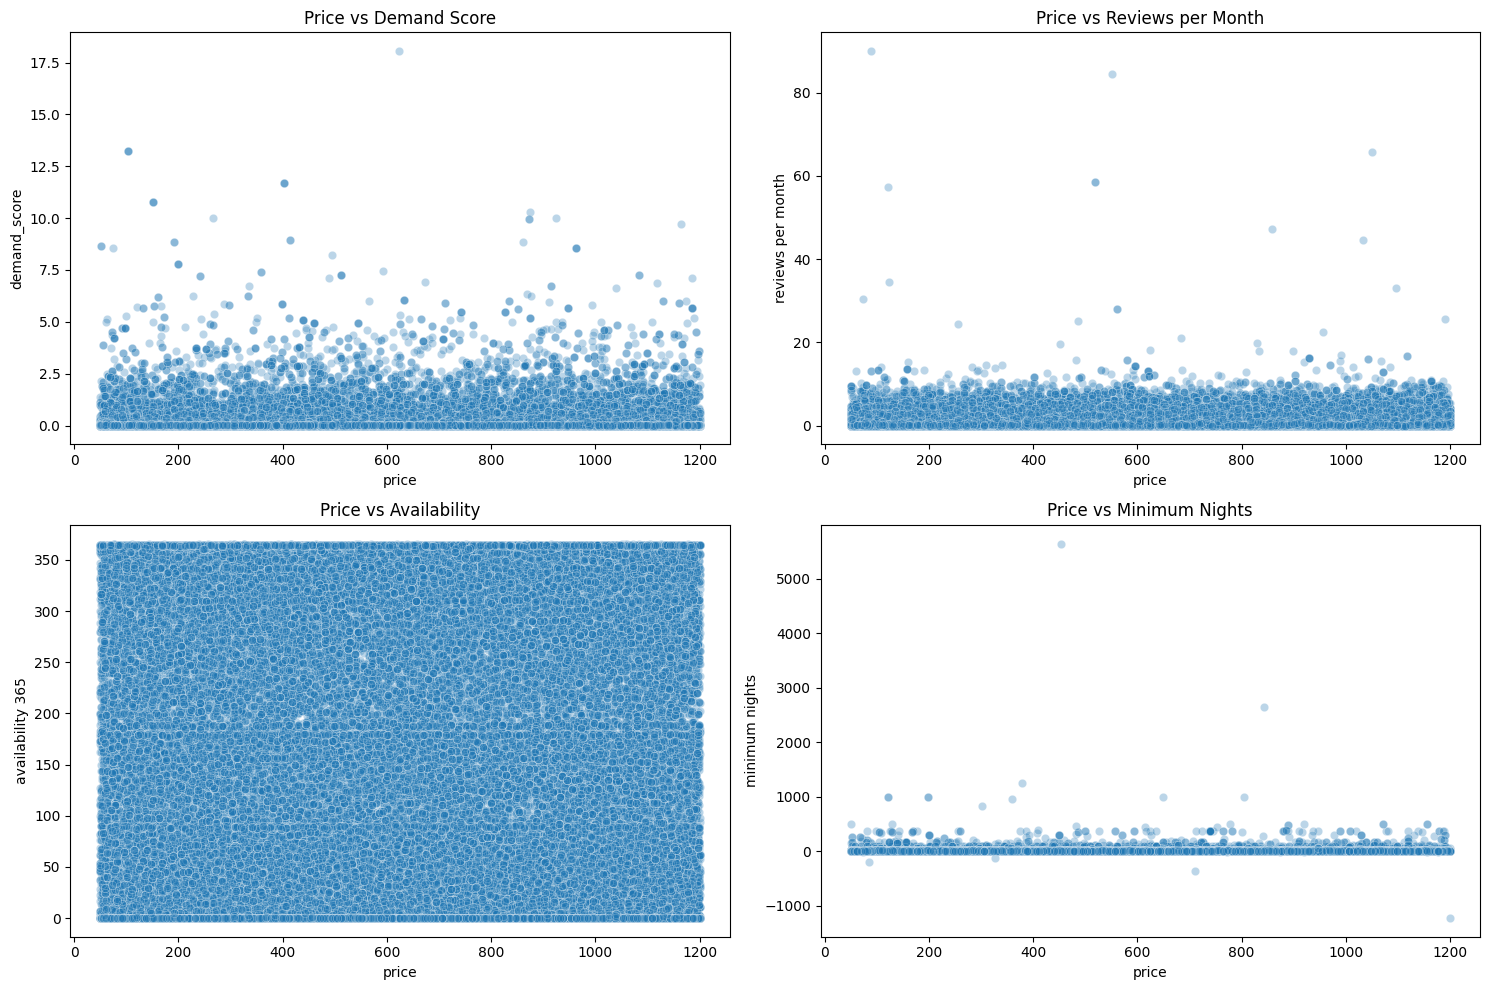

In [5]:
plt.figure(figsize=(15, 10))

# price vs demand
plt.subplot(2, 2, 1)
sns.scatterplot(x=df["price"], y=df["demand_score"], alpha=0.3)
plt.title("Price vs Demand Score")

# price vs reviews
plt.subplot(2, 2, 2)
sns.scatterplot(x=df["price"], y=df["reviews per month"], alpha=0.3)
plt.title("Price vs Reviews per Month")

# price vs availability
plt.subplot(2, 2, 3)
sns.scatterplot(x=df["price"], y=df["availability 365"], alpha=0.3)
plt.title("Price vs Availability")

# price vs minimum nights
plt.subplot(2, 2, 4)
sns.scatterplot(x=df["price"], y=df["minimum nights"], alpha=0.3)
plt.title("Price vs Minimum Nights")

plt.tight_layout()
plt.show()

In [6]:
OUTPUT_DIR = "../artifacts/reports/eda/bivariate_analysis/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.savefig(OUTPUT_DIR + "price_vs_features.png")
plt.close()

In [7]:
corr_cols = [
    "price",
    "demand_score",
    "reviews per month",
    "availability 365",
    "service fee",
    "minimum nights"
]

corr = df[corr_cols].corr()

corr

,price,demand_score,reviews per month,availability 365,service fee,minimum nights
price,1.000000,-0.001298,0.005587,-0.002129,0.997836,-0.005412
demand_score,-0.001298,1.000000,0.192860,-0.279307,-0.001278,-0.030279
reviews per month,0.005587,0.192860,1.000000,0.091548,0.005400,-0.098617
availability 365,-0.002129,-0.279307,0.091548,1.000000,-0.002394,0.069479
service fee,0.997836,-0.001278,0.005400,-0.002394,1.000000,-0.005609
minimum nights,-0.005412,-0.030279,-0.098617,0.069479,-0.005609,1.000000


In [8]:
corr.to_csv(OUTPUT_DIR + "correlations.csv")

print("Saved correlations")

Saved correlations
